In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from huggingface_hub import login
from keras.utils import pad_sequences
from keras.src.legacy.preprocessing.text import Tokenizer
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU
from keras.layers import Bidirectional
from sklearn.metrics import confusion_matrix
import os
import pickle


c:\Emotion Prediction\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()

login(token=os.getenv("HF_TOKEN"))

In [4]:
emotion_dataset= load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']
label_names = emotion_dataset['train'].features['label'].names


<Axes: xlabel='label', ylabel='count'>

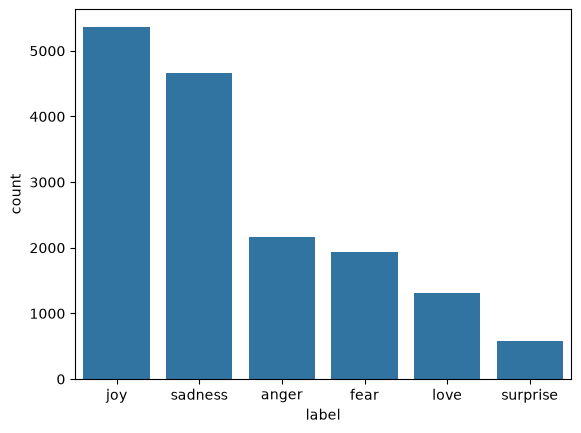

In [5]:
df_train=pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)
df_test=pd.DataFrame(
    {
        'text':test_text,
        'label':[label_names[i] for i in test_label]
    }
)
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)


In [6]:
max_words=10000
tokenizer=Tokenizer(num_words=max_words,oov_token='<ukn>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary size :{len(tokenizer.word_index)}")
print(f"Max Sentence length :{padded_train_sequence.shape[1]}")


Vocabulary size :15213
Max Sentence length :50


In [7]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dic=dict(enumerate(class_weights))


In [8]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


 ### Model 1 — Simple RNN

In [9]:
rnn_models= Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')]
)
rnn_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

rnn_models.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)
rnn_loss, rnn_accuracy = rnn_models.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")


Epoch 1/20


c:\Emotion Prediction\env\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.1649 - loss: 2.0321 - val_accuracy: 0.0490 - val_loss: 1.8654
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.1548 - loss: 1.8828 - val_accuracy: 0.1115 - val_loss: 1.7393
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1419 - loss: 1.8269 - val_accuracy: 0.3475 - val_loss: 1.7763
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1281 - loss: 1.8080 - val_accuracy: 0.2895 - val_loss: 1.7560
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1411 - loss: 1.8009 - val_accuracy: 0.2915 - val_loss: 1.7588
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1115 - loss: 1.7393
RNN Loss: 1.7392860651016235
RNN Accuracy: 0.11150000244379044


 ### Model 2 — LSTM

In [10]:
lstm_models= Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    LSTM(units=128,return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')]
)
lstm_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

lstm_models.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_models.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.1559 - loss: 1.7957 - val_accuracy: 0.0330 - val_loss: 1.8027
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1377 - loss: 1.7938 - val_accuracy: 0.0795 - val_loss: 1.8009
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1491 - loss: 1.7925 - val_accuracy: 0.0820 - val_loss: 1.7859
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1865 - loss: 1.7882 - val_accuracy: 0.0425 - val_loss: 1.8242
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.2206 - loss: 1.7037 - val_accuracy: 0.2830 - val_loss: 1.6752
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3924 - loss: 1.3816 - val_accuracy: 0.3745 - val_loss: 1.3823
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.6271 - loss: 0.8339 - val_accuracy: 0.7315 - val_loss: 0.7585
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8288 - loss: 0.4662 - 

 ### Model 3 — GRU

In [11]:
gru_models= Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    GRU(units=128,return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')]
)
gru_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

gru_models.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_models.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.1468 - loss: 1.7963 - val_accuracy: 0.2900 - val_loss: 1.7782
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1599 - loss: 1.7951 - val_accuracy: 0.0330 - val_loss: 1.8481
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.1601 - loss: 1.7948 - val_accuracy: 0.1140 - val_loss: 1.7972
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.1598 - loss: 1.7936 - val_accuracy: 0.0845 - val_loss: 1.7774
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.1679 - loss: 1.7876 - val_accuracy: 0.1330 - val_loss: 1.8247
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1834 - loss: 1.7552 - val_accuracy: 0.1720 - val_loss: 1.8076
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.2383 - loss: 1.6942 - val_accuracy: 0.1905 - val_loss: 1.8012
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0845 - loss: 1.7774
GRU Loss: 1.7774

In [ ]:
result_df=pd.DataFrame({
    'Model':['Rnn','LSTM','GRU'],
    'Test loss':[rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
})


NameError: name 'rnn_loss' is not defined

 ### Model 4 — BiGRU

In [14]:
BiGRU =Sequential([
    Embedding (input_dim= max_words, output_dim=300, input_length = 50),
    Bidirectional (GRU(128, return_sequences=True)),
    Dropout (0.5),
    Bidirectional (GRU(64)),
    Dropout (0.5),
    Dense(num_classes, activation='softmax')]
)
BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics= ['accuracy'] )

BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {BiGRU_loss}")
print(f"GRU Accuracy: {BiGRU_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.5859 - loss: 1.0401 - val_accuracy: 0.8900 - val_loss: 0.3352
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9169 - loss: 0.2369 - val_accuracy: 0.9065 - val_loss: 0.2594
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.9432 - loss: 0.1487 - val_accuracy: 0.9180 - val_loss: 0.2238
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9561 - loss: 0.1181 - val_accuracy: 0.9170 - val_loss: 0.2625
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9651 - loss: 0.0931 - val_accuracy: 0.9185 - val_loss: 0.2401
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9759 - loss: 0.0649 - val_accuracy: 0.9190 - val_loss: 0.2983
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9180 - loss: 0.2238
GRU Loss: 0.22376181185245514
GRU Accuracy: 0.9179999828338623


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


<Axes: >

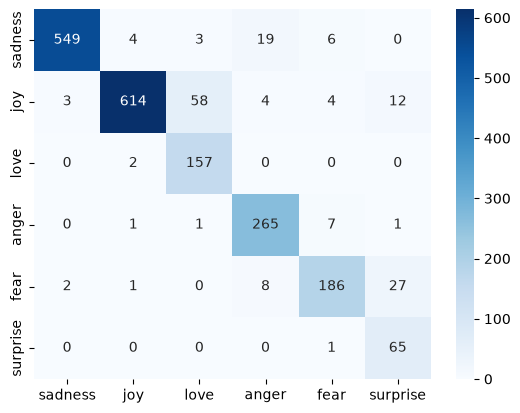

In [16]:
BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)
sns.heatmap(confusion_matrix(test_label,BiGRU_predictions),annot=True,fmt='d',cmap='Blues', xticklabels=label_names, yticklabels=label_names)


In [18]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]
sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences (sample_sequences, maxlen=50, padding='post', truncating='post')
sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [21]:
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai
#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))
#Save the tokenizer
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file: pickle.dump(tokenizer, file)